# Claim Damage Detector — Notebook de Demonstração

Este notebook é apenas para exploração interativa. A implementação de verdade vive em `src/` (veja o README para detalhes e limitações do escopo). Para treinar de fato, prefira os scripts CLI:

```bash
python -m src.train_classifier --epochs 25
python -m src.train_gan --epochs 50
python -m src.predict caminho/imagem.jpg
```

Para a análise exploratória dos dados (EDA), veja `notebooks/01_exploratory_analysis.ipynb`.

In [1]:
import sys
sys.path.append("..") if "src" not in sys.path else None

import matplotlib.pyplot as plt

from src.data import load_classifier_dataset
from src.classifier import build_classifier

Found 1840 files belonging to 2 classes.
Found 460 files belonging to 2 classes.
Classes: ['00-damage', '01-whole']


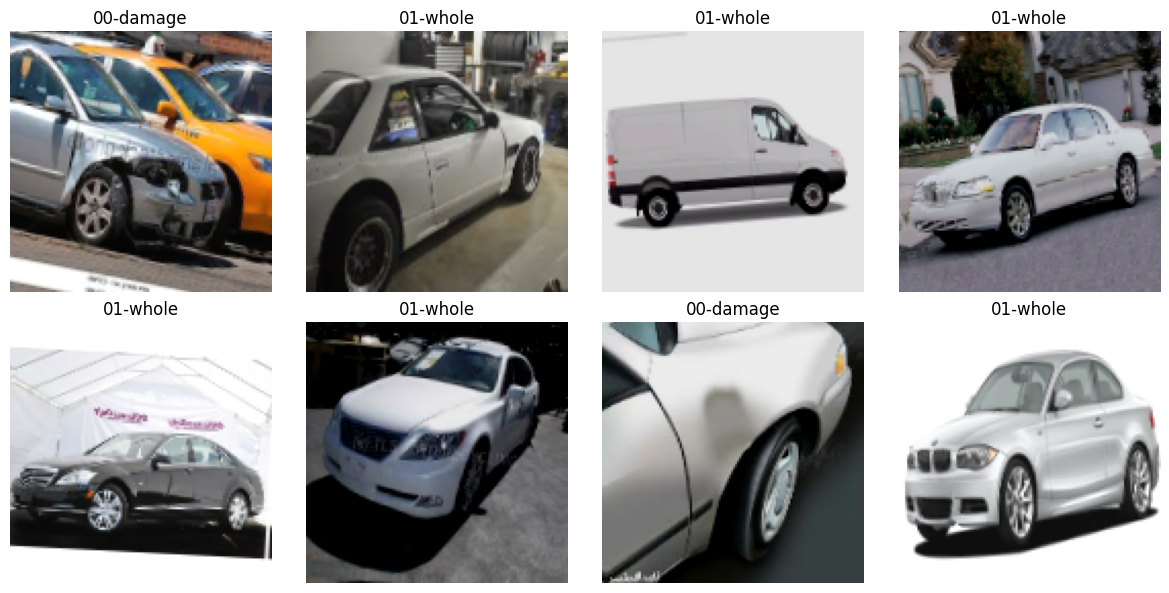

In [2]:
# Requer o dataset baixado (veja README: "Baixar o dataset").
train_ds, val_ds, class_names = load_classifier_dataset()
print("Classes:", class_names)

images, labels = next(iter(train_ds))
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for ax, image, label in zip(axes.ravel(), images, labels):
    ax.imshow(image.numpy())
    ax.set_title(class_names[int(label.numpy()[0])])
    ax.axis("off")
plt.tight_layout()

In [3]:
# Treino rápido para exploração (poucas épocas). Para treino completo use `python -m src.train_classifier`.
model = build_classifier()
history = model.fit(train_ds, validation_data=val_ds, epochs=2)

Epoch 1/2
58/58 ━━━━━━━━━━━━━━━━━━━━ 20s 258ms/step - accuracy: 0.6435 - loss: 0.6588 - val_accuracy: 0.7522 - val_loss: 0.4808
Epoch 2/2
58/58 ━━━━━━━━━━━━━━━━━━━━ 15s 260ms/step - accuracy: 0.7620 - loss: 0.4928 - val_accuracy: 0.7826 - val_loss: 0.4192


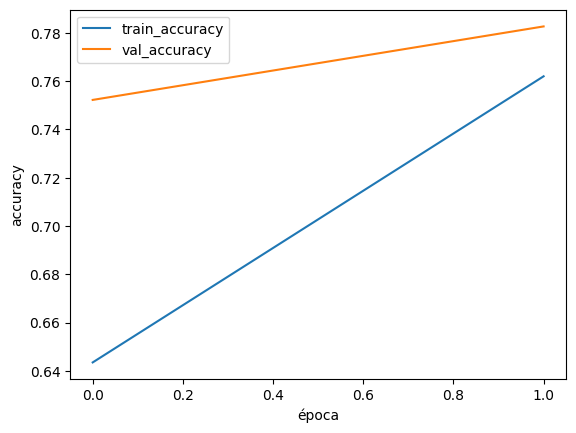

In [4]:
plt.plot(history.history["accuracy"], label="train_accuracy")
plt.plot(history.history["val_accuracy"], label="val_accuracy")
plt.xlabel("época")
plt.ylabel("accuracy")
plt.legend()
plt.show()